In [65]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PowerTransformer
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
from sklearn.ensemble import RandomForestRegressor 

In [66]:
df = pd.read_csv('AirQuality.csv',sep=';')

In [67]:
df.head(100)

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
0,10/03/2004,18.00.00,"2,6",1360.0,150.0,"11,9",1046.0,166.0,1056.0,113.0,1692.0,1268.0,"13,6","48,9","0,7578",NaN,NaN
1,10/03/2004,19.00.00,2,1292.0,112.0,"9,4",955.0,103.0,1174.0,92.0,1559.0,972.0,"13,3","47,7","0,7255",NaN,NaN
2,10/03/2004,20.00.00,"2,2",1402.0,88.0,"9,0",939.0,131.0,1140.0,114.0,1555.0,1074.0,"11,9","54,0","0,7502",NaN,NaN
3,10/03/2004,21.00.00,"2,2",1376.0,80.0,"9,2",948.0,172.0,1092.0,122.0,1584.0,1203.0,"11,0","60,0","0,7867",NaN,NaN
4,10/03/2004,22.00.00,"1,6",1272.0,51.0,"6,5",836.0,131.0,1205.0,116.0,1490.0,1110.0,"11,2","59,6","0,7888",NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,14/03/2004,17.00.00,"2,9",1438.0,156.0,"12,0",1051.0,180.0,943.0,128.0,1668.0,1206.0,"21,3","30,8","0,7696",NaN,NaN
96,14/03/2004,18.00.00,"2,5",1478.0,122.0,"12,2",1055.0,160.0,929.0,121.0,1671.0,1262.0,"19,7","36,7","0,8307",NaN,NaN
97,14/03/2004,19.00.00,"4,6",1808.0,262.0,"20,6",1312.0,261.0,753.0,157.0,1993.0,1698.0,"18,4","41,7","0,8732",NaN,NaN
98,14/03/2004,20.00.00,"5,9",1898.0,341.0,"23,1",1381.0,325.0,681.0,173.0,2103.0,1905.0,"17,6","46,1","0,9210",NaN,NaN


In [68]:
df.duplicated().sum()

np.int64(113)

In [69]:
df=df.drop_duplicates()

In [70]:
df.duplicated().sum()

np.int64(0)

In [71]:
df.drop(['Unnamed: 15','Unnamed: 16'],axis=1,inplace=True)

In [72]:
df

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,10/03/2004,18.00.00,"2,6",1360.0,150.0,"11,9",1046.0,166.0,1056.0,113.0,1692.0,1268.0,"13,6","48,9","0,7578"
1,10/03/2004,19.00.00,2,1292.0,112.0,"9,4",955.0,103.0,1174.0,92.0,1559.0,972.0,"13,3","47,7","0,7255"
2,10/03/2004,20.00.00,"2,2",1402.0,88.0,"9,0",939.0,131.0,1140.0,114.0,1555.0,1074.0,"11,9","54,0","0,7502"
3,10/03/2004,21.00.00,"2,2",1376.0,80.0,"9,2",948.0,172.0,1092.0,122.0,1584.0,1203.0,"11,0","60,0","0,7867"
4,10/03/2004,22.00.00,"1,6",1272.0,51.0,"6,5",836.0,131.0,1205.0,116.0,1490.0,1110.0,"11,2","59,6","0,7888"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9353,04/04/2005,11.00.00,"2,4",1163.0,-200.0,"11,4",1027.0,353.0,604.0,179.0,1264.0,1269.0,"24,3","23,7","0,7119"
9354,04/04/2005,12.00.00,"2,4",1142.0,-200.0,"12,4",1063.0,293.0,603.0,175.0,1241.0,1092.0,"26,9","18,3","0,6406"
9355,04/04/2005,13.00.00,"2,1",1003.0,-200.0,"9,5",961.0,235.0,702.0,156.0,1041.0,770.0,"28,3","13,5","0,5139"
9356,04/04/2005,14.00.00,"2,2",1071.0,-200.0,"11,9",1047.0,265.0,654.0,168.0,1129.0,816.0,"28,5","13,1","0,5028"


In [73]:
df['CO(GT)']=df['CO(GT)'].astype(str).str.replace(',','.').astype(float)
df['C6H6(GT)']=df['C6H6(GT)'].astype(str).str.replace(',','.').astype(float)
df['T']=df['T'].astype(str).str.replace(',','.').astype(float)
df['RH']=df['RH'].astype(str).str.replace(',','.').astype(float)
df['AH']=df['AH'].astype(str).str.replace(',','.').astype(float)

In [74]:
df.head(20)

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888
5,10/03/2004,23.00.00,1.2,1197.0,38.0,4.7,750.0,89.0,1337.0,96.0,1393.0,949.0,11.2,59.2,0.7848
6,11/03/2004,00.00.00,1.2,1185.0,31.0,3.6,690.0,62.0,1462.0,77.0,1333.0,733.0,11.3,56.8,0.7603
7,11/03/2004,01.00.00,1.0,1136.0,31.0,3.3,672.0,62.0,1453.0,76.0,1333.0,730.0,10.7,60.0,0.7702
8,11/03/2004,02.00.00,0.9,1094.0,24.0,2.3,609.0,45.0,1579.0,60.0,1276.0,620.0,10.7,59.7,0.7648
9,11/03/2004,03.00.00,0.6,1010.0,19.0,1.7,561.0,-200.0,1705.0,-200.0,1235.0,501.0,10.3,60.2,0.7517


In [75]:
df.drop(['Date','Time'],axis=1,inplace=True)

In [76]:
df

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
1,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
3,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
4,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9353,2.4,1163.0,-200.0,11.4,1027.0,353.0,604.0,179.0,1264.0,1269.0,24.3,23.7,0.7119
9354,2.4,1142.0,-200.0,12.4,1063.0,293.0,603.0,175.0,1241.0,1092.0,26.9,18.3,0.6406
9355,2.1,1003.0,-200.0,9.5,961.0,235.0,702.0,156.0,1041.0,770.0,28.3,13.5,0.5139
9356,2.2,1071.0,-200.0,11.9,1047.0,265.0,654.0,168.0,1129.0,816.0,28.5,13.1,0.5028


In [79]:
df=df.dropna()

In [80]:
df.isna().sum()

CO(GT)           0
PT08.S1(CO)      0
NMHC(GT)         0
C6H6(GT)         0
PT08.S2(NMHC)    0
NOx(GT)          0
PT08.S3(NOx)     0
NO2(GT)          0
PT08.S4(NO2)     0
PT08.S5(O3)      0
T                0
RH               0
AH               0
dtype: int64

In [81]:
df.head(20)

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
1,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
3,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
4,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888
5,1.2,1197.0,38.0,4.7,750.0,89.0,1337.0,96.0,1393.0,949.0,11.2,59.2,0.7848
6,1.2,1185.0,31.0,3.6,690.0,62.0,1462.0,77.0,1333.0,733.0,11.3,56.8,0.7603
7,1.0,1136.0,31.0,3.3,672.0,62.0,1453.0,76.0,1333.0,730.0,10.7,60.0,0.7702
8,0.9,1094.0,24.0,2.3,609.0,45.0,1579.0,60.0,1276.0,620.0,10.7,59.7,0.7648
9,0.6,1010.0,19.0,1.7,561.0,-200.0,1705.0,-200.0,1235.0,501.0,10.3,60.2,0.7517


In [82]:
common_column =['CO(GT)','NO2(GT)']
data1 = df[common_column + ['C6H6(GT)','NOx(GT)']]
data2 = df[common_column + ['PT08.S1(CO)','PT08.S2(NMHC)','PT08.S3(NOx)','PT08.S4(NO2)','PT08.S5(O3)','T','AH','RH']]

In [83]:
data1_samp = data1.head(100)
data2_samp = data2.head(100)

In [84]:
merged = pd.merge(data1_samp,data2_samp,on=common_column)

In [85]:
merged

,CO(GT),NO2(GT),C6H6(GT),NOx(GT),PT08.S1(CO),PT08.S2(NMHC),PT08.S3(NOx),PT08.S4(NO2),PT08.S5(O3),T,AH,RH
0,2.6,113.0,11.9,166.0,1360.0,1046.0,1056.0,1692.0,1268.0,13.6,0.7578,48.9
1,2.0,92.0,9.4,103.0,1292.0,955.0,1174.0,1559.0,972.0,13.3,0.7255,47.7
2,2.2,114.0,9.0,131.0,1402.0,939.0,1140.0,1555.0,1074.0,11.9,0.7502,54.0
3,2.2,122.0,9.2,172.0,1376.0,948.0,1092.0,1584.0,1203.0,11.0,0.7867,60.0
4,1.6,116.0,6.5,131.0,1272.0,836.0,1205.0,1490.0,1110.0,11.2,0.7888,59.6
...,...,...,...,...,...,...,...,...,...,...,...,...
99,2.9,128.0,12.0,180.0,1438.0,1051.0,943.0,1668.0,1206.0,21.3,0.7696,30.8
100,2.5,121.0,12.2,160.0,1478.0,1055.0,929.0,1671.0,1262.0,19.7,0.8307,36.7
101,4.6,157.0,20.6,261.0,1808.0,1312.0,753.0,1993.0,1698.0,18.4,0.8732,41.7
102,5.9,173.0,23.1,325.0,1898.0,1381.0,681.0,2103.0,1905.0,17.6,0.9210,46.1


In [86]:
concat_col = pd.concat([data1_samp,data2_samp],axis=1)
concat_row = pd.concat([data1_samp,data2_samp],axis=0)

In [87]:
concat_col

,CO(GT),NO2(GT),C6H6(GT),NOx(GT),CO(GT),NO2(GT),PT08.S1(CO),PT08.S2(NMHC),PT08.S3(NOx),PT08.S4(NO2),PT08.S5(O3),T,AH,RH
0,2.6,113.0,11.9,166.0,2.6,113.0,1360.0,1046.0,1056.0,1692.0,1268.0,13.6,0.7578,48.9
1,2.0,92.0,9.4,103.0,2.0,92.0,1292.0,955.0,1174.0,1559.0,972.0,13.3,0.7255,47.7
2,2.2,114.0,9.0,131.0,2.2,114.0,1402.0,939.0,1140.0,1555.0,1074.0,11.9,0.7502,54.0
3,2.2,122.0,9.2,172.0,2.2,122.0,1376.0,948.0,1092.0,1584.0,1203.0,11.0,0.7867,60.0
4,1.6,116.0,6.5,131.0,1.6,116.0,1272.0,836.0,1205.0,1490.0,1110.0,11.2,0.7888,59.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,2.9,128.0,12.0,180.0,2.9,128.0,1438.0,1051.0,943.0,1668.0,1206.0,21.3,0.7696,30.8
96,2.5,121.0,12.2,160.0,2.5,121.0,1478.0,1055.0,929.0,1671.0,1262.0,19.7,0.8307,36.7
97,4.6,157.0,20.6,261.0,4.6,157.0,1808.0,1312.0,753.0,1993.0,1698.0,18.4,0.8732,41.7
98,5.9,173.0,23.1,325.0,5.9,173.0,1898.0,1381.0,681.0,2103.0,1905.0,17.6,0.9210,46.1


In [88]:
concat_row

,CO(GT),NO2(GT),C6H6(GT),NOx(GT),PT08.S1(CO),PT08.S2(NMHC),PT08.S3(NOx),PT08.S4(NO2),PT08.S5(O3),T,AH,RH
0,2.6,113.0,11.9,166.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2.0,92.0,9.4,103.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2.2,114.0,9.0,131.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2.2,122.0,9.2,172.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1.6,116.0,6.5,131.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
95,2.9,128.0,NaN,NaN,1438.0,1051.0,943.0,1668.0,1206.0,21.3,0.7696,30.8
96,2.5,121.0,NaN,NaN,1478.0,1055.0,929.0,1671.0,1262.0,19.7,0.8307,36.7
97,4.6,157.0,NaN,NaN,1808.0,1312.0,753.0,1993.0,1698.0,18.4,0.8732,41.7
98,5.9,173.0,NaN,NaN,1898.0,1381.0,681.0,2103.0,1905.0,17.6,0.9210,46.1


In [89]:
from sklearn.preprocessing import MinMaxScaler

In [92]:
scaler = MinMaxScaler()
num_cols = df.select_dtypes(include=['number']).columns
df[num_cols]=scaler.fit_transform(df[num_cols])
df.head()

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,0.956111,0.696429,0.251980,0.803565,0.516156,0.217987,0.435657,0.579630,0.635966,0.539111,0.873262,0.862141,0.992715
1,0.953280,0.666071,0.224622,0.794084,0.478459,0.180465,0.476587,0.540741,0.591261,0.430408,0.872036,0.857984,0.992556
2,0.954224,0.715179,0.207343,0.792567,0.471831,0.197141,0.464794,0.581481,0.589916,0.467866,0.866312,0.879806,0.992678
3,0.954224,0.703571,0.201584,0.793326,0.475559,0.221560,0.448144,0.596296,0.599664,0.515241,0.862633,0.900589,0.992858
4,0.951392,0.657143,0.180706,0.783087,0.429163,0.197141,0.487340,0.585185,0.568067,0.481087,0.863451,0.899203,0.992869


Text(0.5, 1.0, 'BoxPlot')

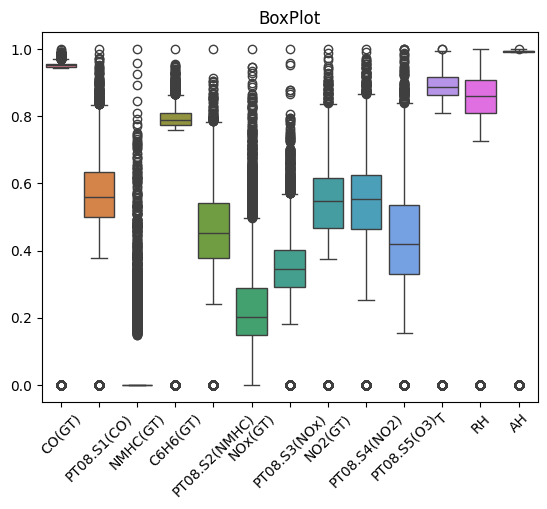

In [93]:
sns.boxplot(df)
plt.xticks(rotation=45)
plt.title('BoxPlot')

In [101]:
def remove_outliers(df,lower=0.01,upper=0.99):
  df = df.copy()
  df_numeric = df.select_dtypes(include=['number']).columns
  for col in df_numeric:
      low=df[col].quantile(lower)
      high=df[col].quantile(upper)
      df = df[(df[col] >= low) & (df[col] <= high)]
  return df.reset_index(drop = True)

In [ ]:
cleaned_data = remove_outliers(df)

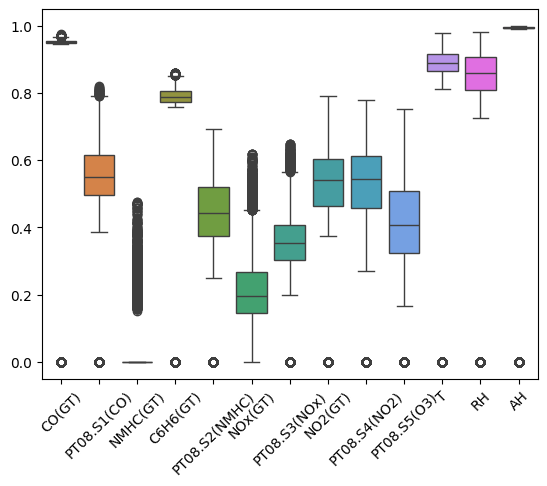

In [104]:
sns.boxplot(cleaned_data)
plt.xticks(rotation=45)
plt.show()

In [116]:
X = df.drop('T',axis=1)
Y = df['T']
X_train,X_test,y_train,y_test =  train_test_split(X,Y,test_size=0.2,random_state =10)

lr=LinearRegression()
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_test)

dr=DecisionTreeRegressor()
dr.fit(X_train,y_train)
dr_preds = dr.predict(X_test)

rf=RandomForestRegressor()
rf.fit(X_train,y_train)
rf_preds = rf.predict(X_test)

def evaluate(model_name,y_test,predictions):
    print(f"\n{model_name}Results:")
    print(f"R2 score:{r2_score(y_test,predictions):.2f}")
    print(f"MAE:{mean_absolute_error(y_test,predictions):.2f}")
    print(f"MSE:{mean_squared_error(y_test,predictions):.2f}")
    print(f"Accuracy:{r2_score(y_test,predictions)*100:.2f}")
    
evaluate("Linear Regression",y_test,lr_preds)
evaluate("decision Tree",y_test,dr_preds)
evaluate("Random Forest",y_test,rf_preds)


Linear RegressionResults:
R2 score:0.99
MAE:0.01
MSE:0.00
Accuracy:99.39

decision TreeResults:
R2 score:1.00
MAE:0.00
MSE:0.00
Accuracy:99.98

Random ForestResults:
R2 score:1.00
MAE:0.00
MSE:0.00
Accuracy:100.00
